Objectives:
1. We need to identify the risk analytics for banks so as to reduce their risk exposure
2. We need to identify the categories that are at highest risk of default
3. Identify categories that are at lowest risk of default so that they can be provided loans

Filtering out the warnings

In [8]:
import warnings
warnings.filterwarnings('ignore')

Importing the required libraries

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Mounting Google Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Reading file using read_csv

In [81]:
app = pd.read_csv("/content/drive/MyDrive/application_data.csv")
app.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
app.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

Finding out number of rows and columns

In [13]:
app.shape

(307511, 122)

Finding out the number of rows and columns of previous application dataset

Find shape, Info & Description of the data set

In [14]:
app.info(verbose=True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [15]:
app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


Null Columns

In [16]:
null_values = app.isnull().sum()
null_columns = null_values[null_values > 0]
print(null_columns)

AMT_ANNUITY                       12
AMT_GOODS_PRICE                  278
NAME_TYPE_SUITE                 1292
OWN_CAR_AGE                   202929
OCCUPATION_TYPE                96391
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
Length: 67, dtype: int64


Making an exception for EXT_SOURCE_1

In [17]:
median_ext_source_1 = app['EXT_SOURCE_1'].median()
app['EXT_SOURCE_1'].fillna(median_ext_source_1, inplace=True)

Remove all columns with > 30/40% nulls

In [18]:
col_miss_30 = app.isnull().sum()/len(app) * 100
drop_col = col_miss_30[col_miss_30 > 30].index
#print(drop_col)
app.drop(drop_col, axis = 1, inplace = True)
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

Checking columns with Null values in between 10 and 30

In [19]:
col_10_30 = app.isnull().sum()/len(app) * 100
ins_column_10_30 = col_10_30[(col_10_30>10) & (col_10_30<30)].index
app[ins_column_10_30].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   EXT_SOURCE_3                246546 non-null  float64
 1   AMT_REQ_CREDIT_BUREAU_HOUR  265992 non-null  float64
 2   AMT_REQ_CREDIT_BUREAU_DAY   265992 non-null  float64
 3   AMT_REQ_CREDIT_BUREAU_WEEK  265992 non-null  float64
 4   AMT_REQ_CREDIT_BUREAU_MON   265992 non-null  float64
 5   AMT_REQ_CREDIT_BUREAU_QRT   265992 non-null  float64
 6   AMT_REQ_CREDIT_BUREAU_YEAR  265992 non-null  float64
dtypes: float64(7)
memory usage: 16.4 MB


Filling important parameter with median

In [20]:
app['EXT_SOURCE_3'].fillna(app['EXT_SOURCE_3'].median(), inplace=True)

Filling other parameters with 0

In [21]:
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

app[bureau_cols] = app[bureau_cols].fillna(0)

Checking our application dataset again

In [22]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

Checking default rate by gender

In [23]:
app['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


In [24]:
app.drop(app[app['CODE_GENDER'] == 'XNA'].index, axis = 0, inplace=True)

In [25]:
app['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,202448
M,105059


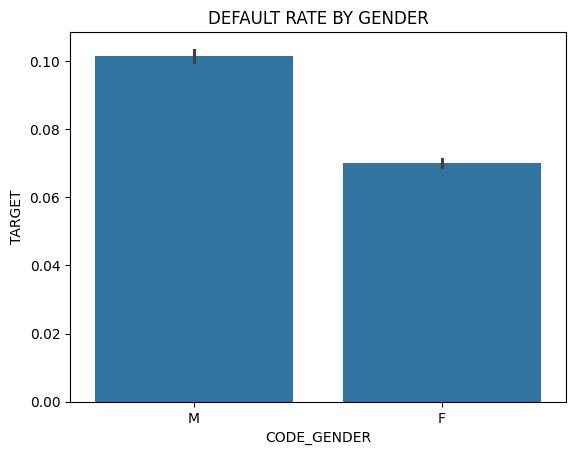

In [26]:
sns.barplot(data = app, x = 'CODE_GENDER', y = 'TARGET')
plt.title('DEFAULT RATE BY GENDER')
plt.show()

Checking credit amount of loan

In [27]:
app['AMT_CREDIT'].info()

<class 'pandas.core.series.Series'>
Index: 307507 entries, 0 to 307510
Series name: AMT_CREDIT
Non-Null Count   Dtype  
--------------   -----  
307507 non-null  float64
dtypes: float64(1)
memory usage: 4.7 MB


In [28]:
app['AMT_CREDIT'].mean()

np.float64(599028.5967327573)

In [29]:
app['AMT_CREDIT'].median()

513531.0

Calculation of default rate by education

In [30]:
app['NAME_EDUCATION_TYPE'].info()

<class 'pandas.core.series.Series'>
Index: 307507 entries, 0 to 307510
Series name: NAME_EDUCATION_TYPE
Non-Null Count   Dtype 
--------------   ----- 
307507 non-null  object
dtypes: object(1)
memory usage: 4.7+ MB


In [31]:
app['NAME_EDUCATION_TYPE'].describe()

,NAME_EDUCATION_TYPE
count,307507
unique,5
top,Secondary / secondary special
freq,218389


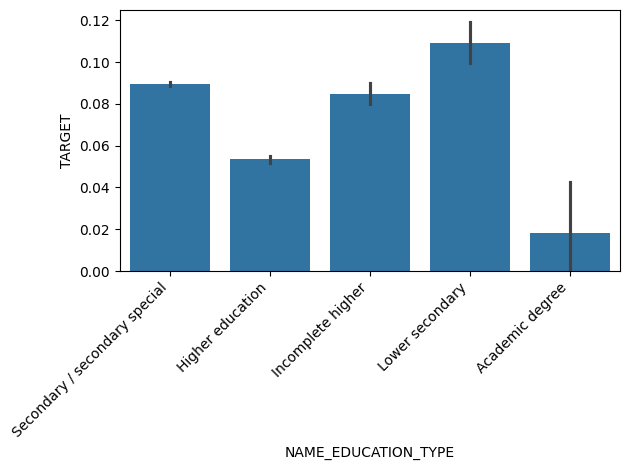

In [32]:
sns.barplot(data = app, x = 'NAME_EDUCATION_TYPE', y = 'TARGET')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

Checking default rate by family status

In [33]:
app['NAME_FAMILY_STATUS'].info()

<class 'pandas.core.series.Series'>
Index: 307507 entries, 0 to 307510
Series name: NAME_FAMILY_STATUS
Non-Null Count   Dtype 
--------------   ----- 
307507 non-null  object
dtypes: object(1)
memory usage: 4.7+ MB


In [34]:
app['NAME_FAMILY_STATUS'].unique()

array(['Single / not married', 'Married', 'Civil marriage', 'Widow',
       'Separated', 'Unknown'], dtype=object)

In [35]:
app['NAME_FAMILY_STATUS'] = app['NAME_FAMILY_STATUS'].replace('Single / not married', 'Unmarried')

In [36]:
app['NAME_FAMILY_STATUS'].unique()

array(['Unmarried', 'Married', 'Civil marriage', 'Widow', 'Separated',
       'Unknown'], dtype=object)

In [37]:
app.drop(app[app['NAME_FAMILY_STATUS'] == 'Unknown'].index, inplace = True)

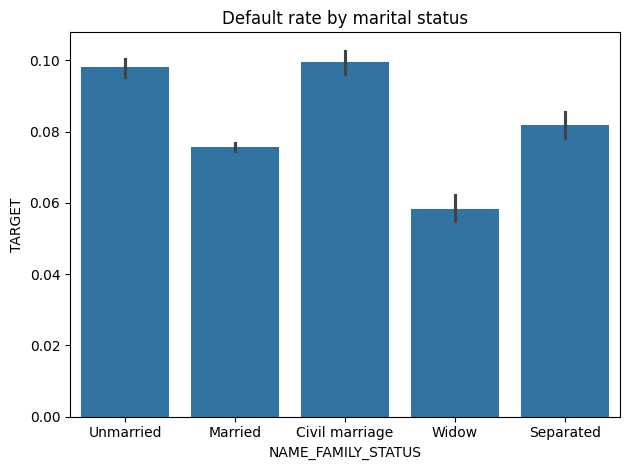

In [38]:
sns.barplot(data = app, x = 'NAME_FAMILY_STATUS', y = 'TARGET')
plt.title('Default rate by marital status')
plt.tight_layout()
plt.show()

From the above 2 plots we can assess that Married persons and Females are on an average at lower risk of default

In [39]:
app.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE',
       'DEF_30_CNT_

Removing columns that do not have considerable significance for understanding data

In [40]:
doc_cols = [col for col in app.columns if 'FLAG_DOCUMENT' in col]
app.drop(doc_cols, axis = 1, inplace=True)
app.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE',
       'DEF_30_CNT_

In [41]:
app['AMT_ANNUITY'].info()

<class 'pandas.core.series.Series'>
Index: 307505 entries, 0 to 307510
Series name: AMT_ANNUITY
Non-Null Count   Dtype  
--------------   -----  
307493 non-null  float64
dtypes: float64(1)
memory usage: 4.7 MB


In [42]:
app['AMT_ANNUITY'].isnull().sum()

np.int64(12)

In [43]:
median_annuity = app['AMT_ANNUITY'].median()
app['AMT_ANNUITY'].fillna(median_annuity, inplace=True)
app['AMT_ANNUITY'].info()

<class 'pandas.core.series.Series'>
Index: 307505 entries, 0 to 307510
Series name: AMT_ANNUITY
Non-Null Count   Dtype  
--------------   -----  
307505 non-null  float64
dtypes: float64(1)
memory usage: 4.7 MB


Checking for outliers

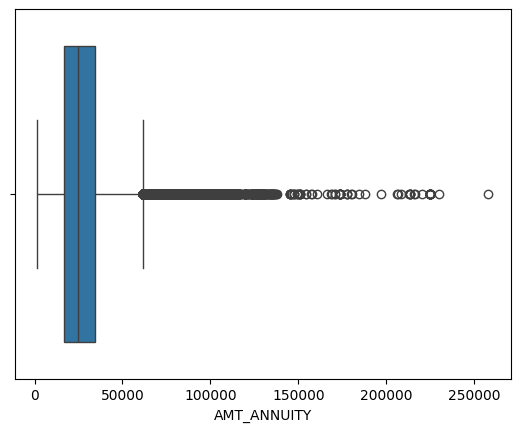

In [44]:
sns.boxplot(data = app, x = 'AMT_ANNUITY')
plt.show()

In [45]:
app['AMT_GOODS_PRICE'].isnull().sum()

np.int64(276)

In [46]:
amt_goods_price_median = app['AMT_GOODS_PRICE'].median()
app['AMT_GOODS_PRICE'].fillna(amt_goods_price_median, inplace=True)

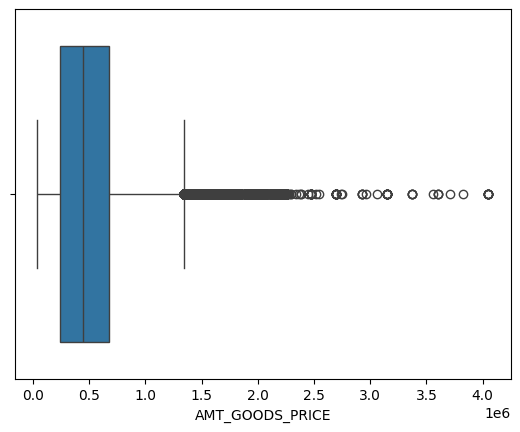

In [47]:
sns.boxplot(data = app, x = 'AMT_GOODS_PRICE')
plt.show()

Imputing values of External Source 2

In [48]:
median_ext_source_2 = app['EXT_SOURCE_2'].median()
app['EXT_SOURCE_2'].fillna(median_ext_source_2, inplace=True)

Checking usefulness of below columns

In [49]:
app['NAME_TYPE_SUITE'].info()

<class 'pandas.core.series.Series'>
Index: 307505 entries, 0 to 307510
Series name: NAME_TYPE_SUITE
Non-Null Count   Dtype 
--------------   ----- 
306215 non-null  object
dtypes: object(1)
memory usage: 4.7+ MB


In [50]:
app['NAME_TYPE_SUITE'].unique()

array(['Unaccompanied', 'Family', 'Spouse, partner', 'Children',
       'Other_A', nan, 'Other_B', 'Group of people'], dtype=object)

The above column does not seem to be useful for further exploration of data, so dropping it

In [51]:
app.drop('NAME_TYPE_SUITE', axis = 1, inplace = True)

In [52]:
app.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307505 entries, 0 to 307510
Data columns (total 52 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307505 non-null  int64  
 1   TARGET                       307505 non-null  int64  
 2   NAME_CONTRACT_TYPE           307505 non-null  object 
 3   CODE_GENDER                  307505 non-null  object 
 4   FLAG_OWN_CAR                 307505 non-null  object 
 5   FLAG_OWN_REALTY              307505 non-null  object 
 6   CNT_CHILDREN                 307505 non-null  int64  
 7   AMT_INCOME_TOTAL             307505 non-null  float64
 8   AMT_CREDIT                   307505 non-null  float64
 9   AMT_ANNUITY                  307505 non-null  float64
 10  AMT_GOODS_PRICE              307505 non-null  float64
 11  NAME_INCOME_TYPE             307505 non-null  object 
 12  NAME_EDUCATION_TYPE          307505 non-null  object 
 13  NAME

Understanding correlations

In [53]:
corr = app.corr(numeric_only=True)

<Axes: >

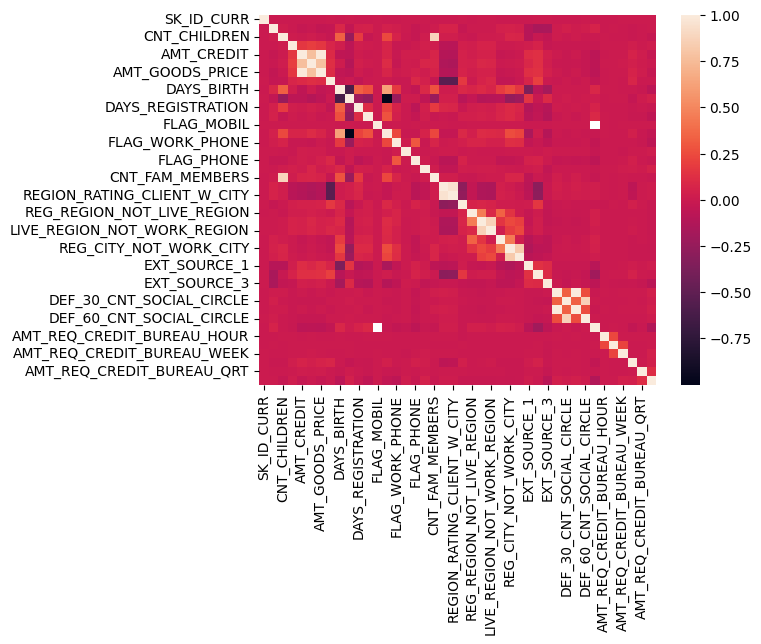

In [54]:
sns.heatmap(corr)

In [55]:
corr['TARGET'].sort_values(ascending=False).head(15)

,TARGET
TARGET,1.000000
DAYS_BIRTH,0.078244
REGION_RATING_CLIENT_W_CITY,0.060895
REGION_RATING_CLIENT,0.058901
DAYS_LAST_PHONE_CHANGE,0.055220
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045985
REG_CITY_NOT_LIVE_CITY,0.044394
DAYS_REGISTRATION,0.041978


For above it seems that target does not have strong correlations with any variable

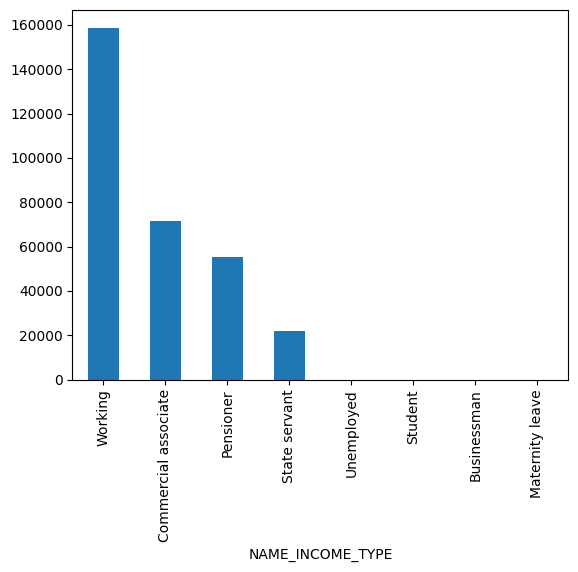

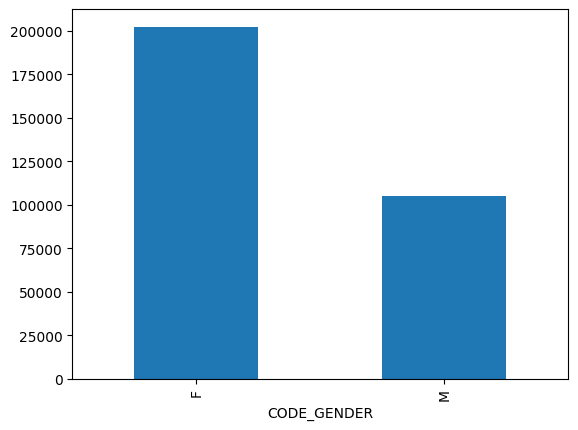

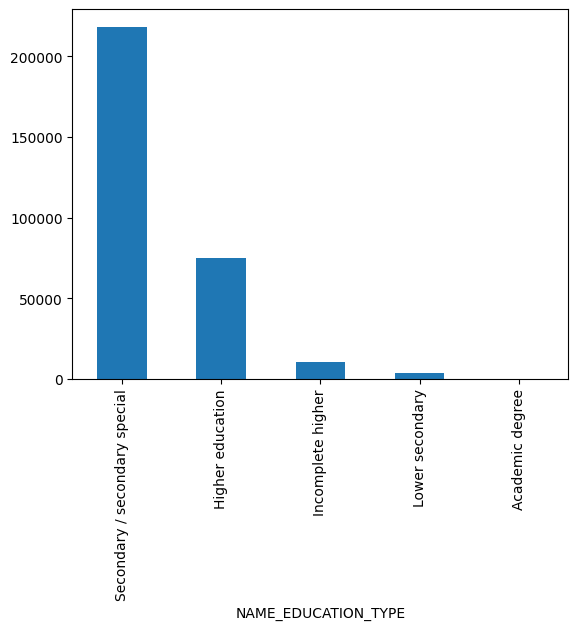

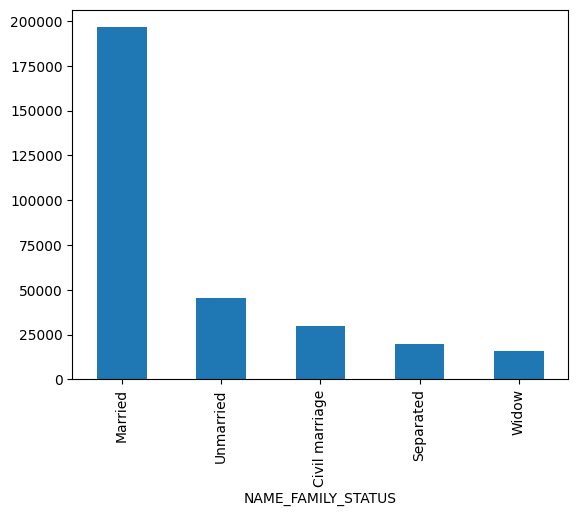

In [56]:
#### Univariate Analysis

### Pick one variable and understand the counts/ group by sums/ plot bar charts/ distributions  - Employee distrbution -> Salaried class are the most applicants in a loan setting

### Salaried class Employees are the ones with highest loan rejections

univ = ['NAME_INCOME_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

for col in univ:
  app[col].value_counts().plot.bar()
  plt.show()

Based on the  above charts we can determine that married, working class professionals have the highest frequency of loan application

Also the application of females is considerably higher than that of males

Secondary education dominates the default pool

In [57]:
app['AMT_INCOME_TOTAL'].head(15)

,AMT_INCOME_TOTAL
0,202500.000
1,270000.000
2,67500.000
3,135000.000
4,121500.000
5,99000.000
6,171000.000
7,360000.000
8,112500.000
9,135000.000


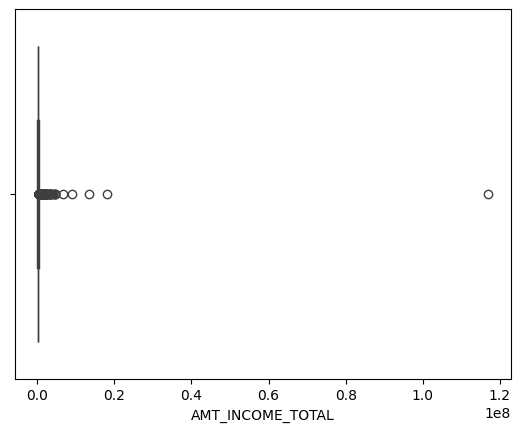

In [58]:
sns.boxplot(data = app, x = 'AMT_INCOME_TOTAL')
plt.show()

For above, extreme outliers distort the boxplot.
Initiating removing process below

In [59]:
q_25 = app['AMT_INCOME_TOTAL'].quantile(.25)
q_75 = app['AMT_INCOME_TOTAL'].quantile(.75)
IQR = q_75 - q_25
whiskers = IQR*1.5
lower_bound = q_25 - whiskers
upper_bound = q_75 + whiskers
app = app[(app['AMT_INCOME_TOTAL'] >= lower_bound) & (app['AMT_INCOME_TOTAL'] <= upper_bound)]

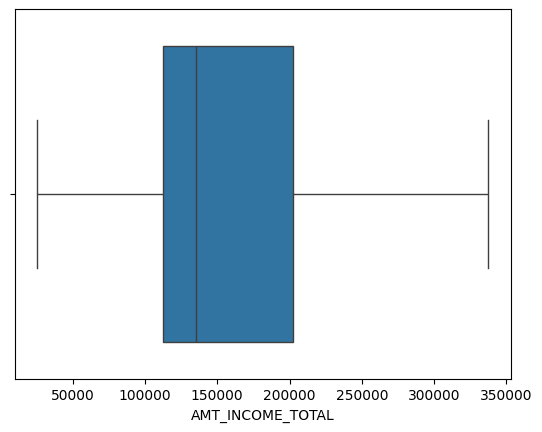

In [60]:
sns.boxplot(data = app, x = 'AMT_INCOME_TOTAL')
plt.show()

Above data now shows the significant income level of applicants

In [61]:
app.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293471 entries, 0 to 307510
Data columns (total 52 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   293471 non-null  int64  
 1   TARGET                       293471 non-null  int64  
 2   NAME_CONTRACT_TYPE           293471 non-null  object 
 3   CODE_GENDER                  293471 non-null  object 
 4   FLAG_OWN_CAR                 293471 non-null  object 
 5   FLAG_OWN_REALTY              293471 non-null  object 
 6   CNT_CHILDREN                 293471 non-null  int64  
 7   AMT_INCOME_TOTAL             293471 non-null  float64
 8   AMT_CREDIT                   293471 non-null  float64
 9   AMT_ANNUITY                  293471 non-null  float64
 10  AMT_GOODS_PRICE              293471 non-null  float64
 11  NAME_INCOME_TYPE             293471 non-null  object 
 12  NAME_EDUCATION_TYPE          293471 non-null  object 
 13  NAME

<Axes: xlabel='INCOME_BIN', ylabel='TARGET'>

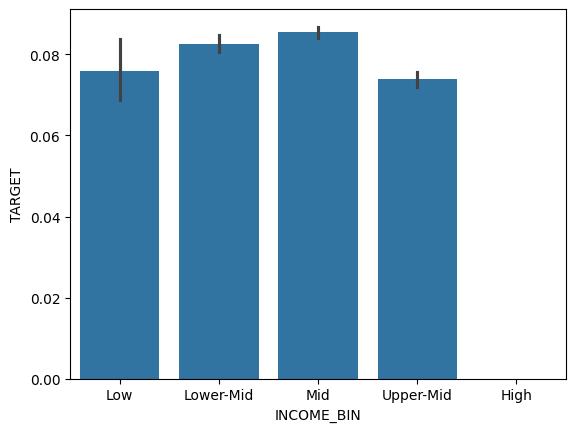

In [62]:
### Some variables like Income, Credit History etc would be better to be analysed using bins - create 10/15 bins for this
#l = ['2-100','101-200']
#bins = [0,100,200]
#pd.cut(df.var_name, bins, labels = l)
income_bins = [0,50000,100000,200000,500000,1000000]
labels = ['Low','Lower-Mid','Mid','Upper-Mid','High']

app['INCOME_BIN'] = pd.cut(
    app['AMT_INCOME_TOTAL'],
    bins=income_bins,
    labels=labels
)
sns.barplot(x='INCOME_BIN', y='TARGET', data=app)

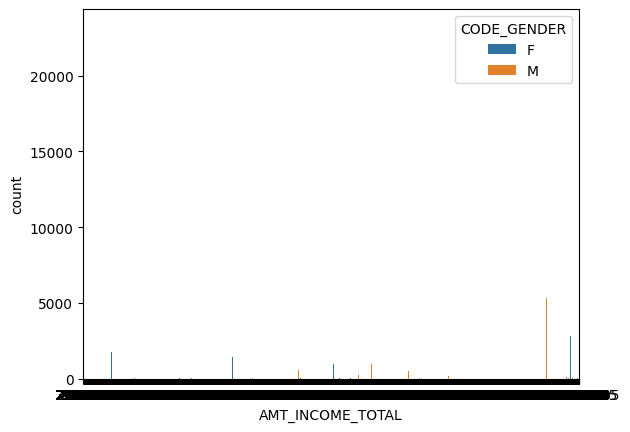

In [63]:
sns.countplot(data=app, x='AMT_INCOME_TOTAL', hue='CODE_GENDER')
plt.show()

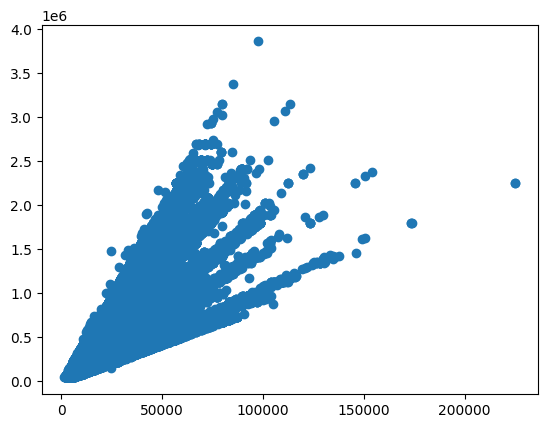

In [64]:
plt.scatter(app['AMT_ANNUITY'], app['AMT_CREDIT'])
plt.show()

Feature Engineering

In [65]:
app['ESTIMATED_LOAN_TERM'] = app['AMT_CREDIT'] / app['AMT_ANNUITY']
app.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293471 entries, 0 to 307510
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   SK_ID_CURR                   293471 non-null  int64   
 1   TARGET                       293471 non-null  int64   
 2   NAME_CONTRACT_TYPE           293471 non-null  object  
 3   CODE_GENDER                  293471 non-null  object  
 4   FLAG_OWN_CAR                 293471 non-null  object  
 5   FLAG_OWN_REALTY              293471 non-null  object  
 6   CNT_CHILDREN                 293471 non-null  int64   
 7   AMT_INCOME_TOTAL             293471 non-null  float64 
 8   AMT_CREDIT                   293471 non-null  float64 
 9   AMT_ANNUITY                  293471 non-null  float64 
 10  AMT_GOODS_PRICE              293471 non-null  float64 
 11  NAME_INCOME_TYPE             293471 non-null  object  
 12  NAME_EDUCATION_TYPE          293471 non-null  obj

Plotting default probability to the term of the loan

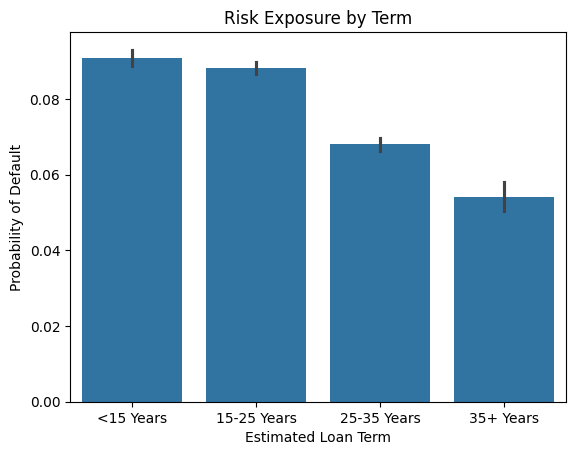

In [66]:
app['TERM_BUCKET'] = pd.cut(app['ESTIMATED_LOAN_TERM'],
                            bins=[0, 15, 25, 35, 50],
                            labels=['<15 Years', '15-25 Years', '25-35 Years', '35+ Years'])


sns.barplot(data=app, x='TERM_BUCKET', y='TARGET')

plt.ylabel('Probability of Default')
plt.xlabel('Estimated Loan Term')
plt.title('Risk Exposure by Term')
plt.show()

Above graph shows that lower term loans are at highest risk of default

Loading previous application dataset

In [67]:
prev = pd.read_csv("/content/drive/MyDrive/previous_application.csv")
prev.head(10)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
5,1383531,199383,Cash loans,23703.930,315000.0,340573.5,NaN,315000.0,SATURDAY,8,...,XNA,18.0,low_normal,Cash X-Sell: low,365243.0,-654.0,-144.0,-144.0,-137.0,1.0
6,2315218,175704,Cash loans,NaN,0.0,0.0,NaN,NaN,TUESDAY,11,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
7,1656711,296299,Cash loans,NaN,0.0,0.0,NaN,NaN,MONDAY,7,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
8,2367563,342292,Cash loans,NaN,0.0,0.0,NaN,NaN,MONDAY,15,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
9,2579447,334349,Cash loans,NaN,0.0,0.0,NaN,NaN,SATURDAY,15,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
prev.info(verbose = True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [69]:
prev.shape

(1670214, 37)

In [70]:
prev_null = prev.isnull().sum()/len(prev)
null_values_prev = prev_null[prev_null > 0.3].index
null_values_prev

Index(['AMT_DOWN_PAYMENT', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_TYPE_SUITE', 'DAYS_FIRST_DRAWING',
       'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE',
       'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='object')

In [71]:
prev.drop(null_values_prev, axis=1, inplace=True)
prev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 26 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_GOODS_PRICE              1284699 non-null  float64
 7   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 8   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 9   FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 10  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 11  NAME_CASH_LOAN_PURPOSE       1670214 non-null  object 
 12  NAME_CONTRACT_STATUS         1670214 non-n

In [72]:
prev['PRODUCT_COMBINATION'].isnull().sum()

np.int64(346)

Since the above is a very small percentage of our total rows, we would prefer to drop it

In [73]:
prev.dropna(subset = ['PRODUCT_COMBINATION'], inplace=True)


Checking null values of other columns

In [74]:
prev['AMT_ANNUITY'].isnull().sum()

np.int64(371889)

Not filling the above value, since its a footprint of rejected/not approved application

In [75]:
prev['AMT_GOODS_PRICE'].isnull().sum()

np.int64(385169)

Not filling the above value or imputing with mean since its would distort personal loans

In [76]:
prev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1669868 entries, 0 to 1670213
Data columns (total 26 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1669868 non-null  int64  
 1   SK_ID_CURR                   1669868 non-null  int64  
 2   NAME_CONTRACT_TYPE           1669868 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1669868 non-null  float64
 5   AMT_CREDIT                   1669867 non-null  float64
 6   AMT_GOODS_PRICE              1284699 non-null  float64
 7   WEEKDAY_APPR_PROCESS_START   1669868 non-null  object 
 8   HOUR_APPR_PROCESS_START      1669868 non-null  int64  
 9   FLAG_LAST_APPL_PER_CONTRACT  1669868 non-null  object 
 10  NFLAG_LAST_APPL_IN_DAY       1669868 non-null  int64  
 11  NAME_CASH_LOAN_PURPOSE       1669868 non-null  object 
 12  NAME_CONTRACT_STATUS         1669868 non-null  

In [77]:
## Purpose of previous laon , contract status with previopsu loan

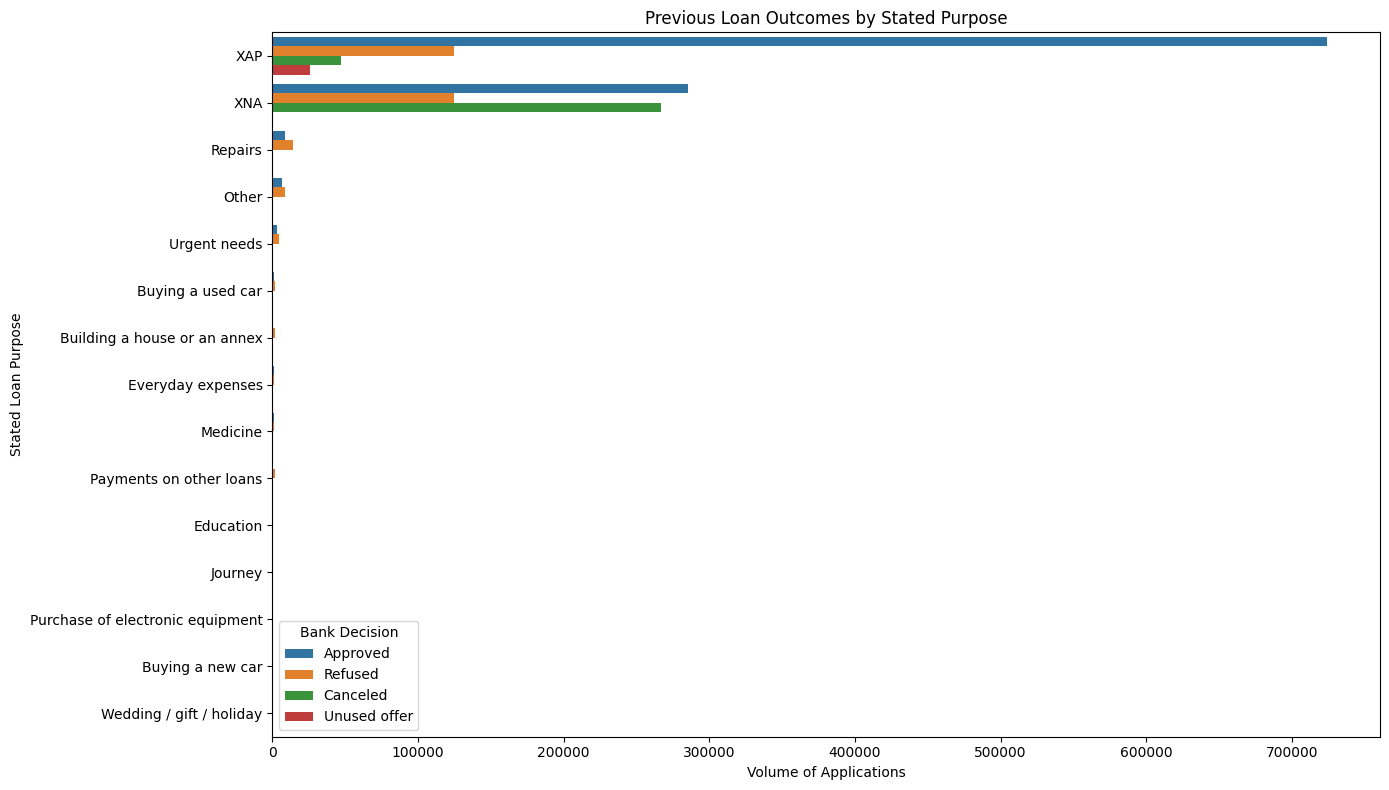

In [78]:
plt.figure(figsize=(14, 8))

sns.countplot(data=prev,
              y='NAME_CASH_LOAN_PURPOSE',
              hue='NAME_CONTRACT_STATUS',
              order=prev['NAME_CASH_LOAN_PURPOSE'].value_counts().head(15).index)

plt.title('Previous Loan Outcomes by Stated Purpose')
plt.xlabel('Volume of Applications')
plt.ylabel('Stated Loan Purpose')
plt.legend(title='Bank Decision')
plt.tight_layout()
plt.show()

Since we are unable to get true representation due to XNA and XAP, we would be hiding those specific rows

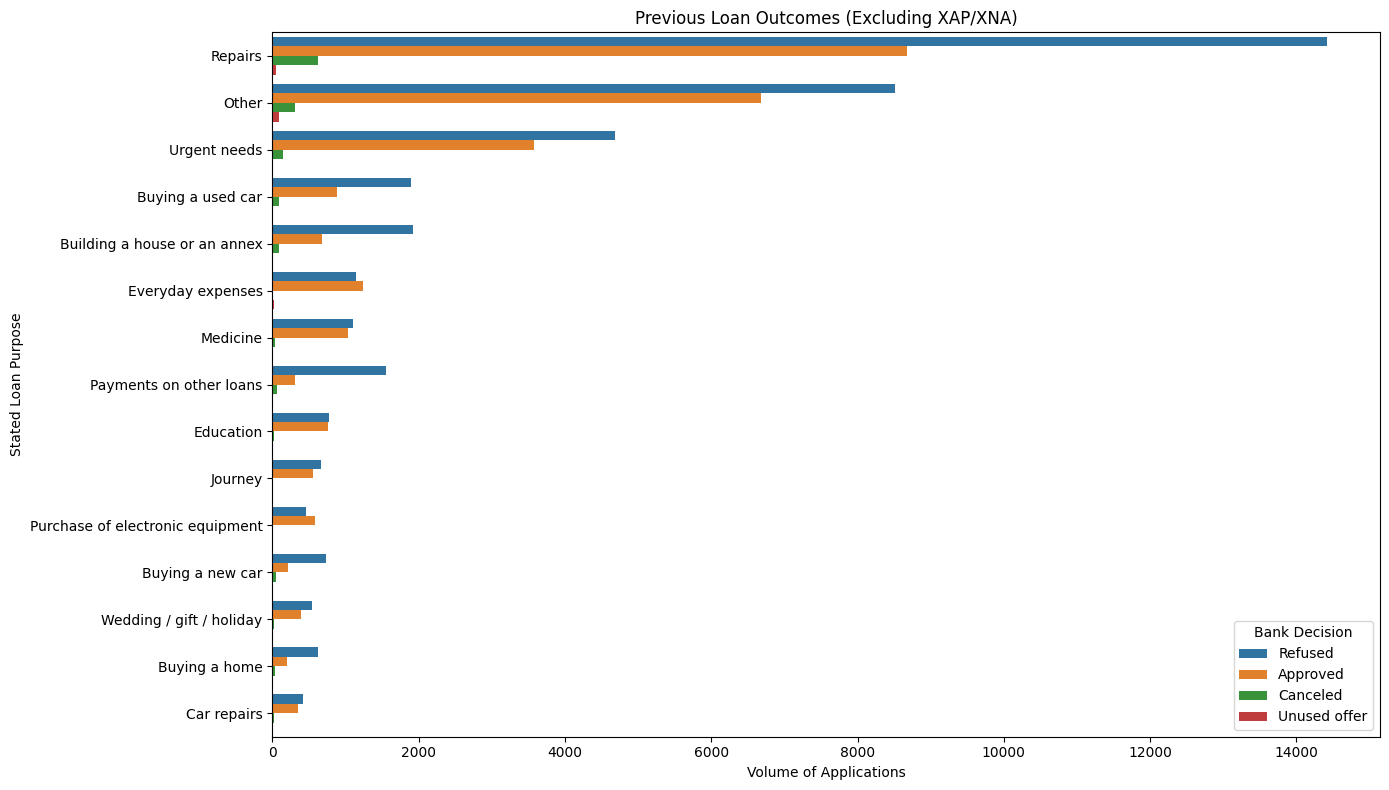

In [79]:
mask = ~prev['NAME_CASH_LOAN_PURPOSE'].isin(['XAP', 'XNA'])
filtered_prev = prev[mask]

plt.figure(figsize=(14, 8))

sns.countplot(data=filtered_prev,
              y='NAME_CASH_LOAN_PURPOSE',
              hue='NAME_CONTRACT_STATUS',
              order=filtered_prev['NAME_CASH_LOAN_PURPOSE'].value_counts().head(15).index)

plt.title('Previous Loan Outcomes (Excluding XAP/XNA)')
plt.xlabel('Volume of Applications')
plt.ylabel('Stated Loan Purpose')
plt.legend(title='Bank Decision')
plt.tight_layout()
plt.show()

The above chart shows that repairs dominate the above application counts for loads

Payment of other loans have a significant proportion of refusal as compared to acceptance



In [80]:
"""
Summary:
1. Males in general have higher tendency to default as compared to females
2. Persons with Academic degree have the least rate of default
3. Married persons and widows have the low rate of default as compared to
other categories
4. Loans with lesser amount of maturity have highest risk exposure, risk exposure
reduces proportionally to increasing term of loans


"""
